In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from dataset import ClockDataset  # ה-Dataset המעודכן שלך

In [2]:

# ===================== 1. Define Model (U-net) =====================
class ClockEraserUNet(nn.Module):
    def __init__(self):
        super(ClockEraserUNet, self).__init__()
        
        # Encoder
        self.enc1 = self.conv_block(3, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = self.conv_block(256 + 128, 128) # Skip connection
        
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = self.conv_block(128 + 64, 64)   # Skip connection
        
        self.final = nn.Conv2d(64, 3, kernel_size=1)

    def conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool(e1)
        
        e2 = self.enc2(p1)
        p2 = self.pool(e2)
        
        e3 = self.enc3(p2) # Bottleneck
        
        # Decoder
        u2 = self.up2(e3)
        # perform interpolation if sizes don't match due to pooling/upsampling
        if u2.size() != e2.size():
            u2 = torch.nn.functional.interpolate(u2, size=e2.shape[2:])
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)
        
        u1 = self.up1(d2)
        if u1.size() != e1.size():
            u1 = torch.nn.functional.interpolate(u1, size=e1.shape[2:])
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)
        
        return torch.sigmoid(self.final(d1)) # Output 0-1 (Image)

Using device: mps
Starting Eraser Training...
Epoch [1/50], Loss: 0.01910
  -> Saved best model!
Epoch [2/50], Loss: 0.00637
  -> Saved best model!
Epoch [3/50], Loss: 0.00364
  -> Saved best model!
Epoch [4/50], Loss: 0.00292
  -> Saved best model!
Epoch [5/50], Loss: 0.00331


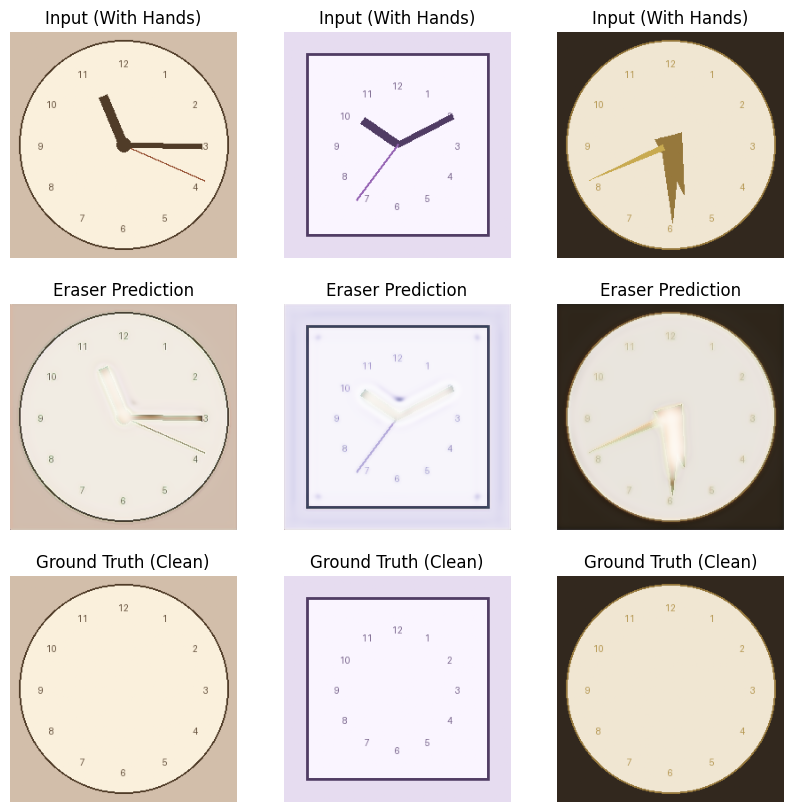

Epoch [6/50], Loss: 0.00232
  -> Saved best model!
Epoch [7/50], Loss: 0.00191
  -> Saved best model!
Epoch [8/50], Loss: 0.00173
  -> Saved best model!
Epoch [9/50], Loss: 0.00128
  -> Saved best model!
Epoch [10/50], Loss: 0.00120
  -> Saved best model!


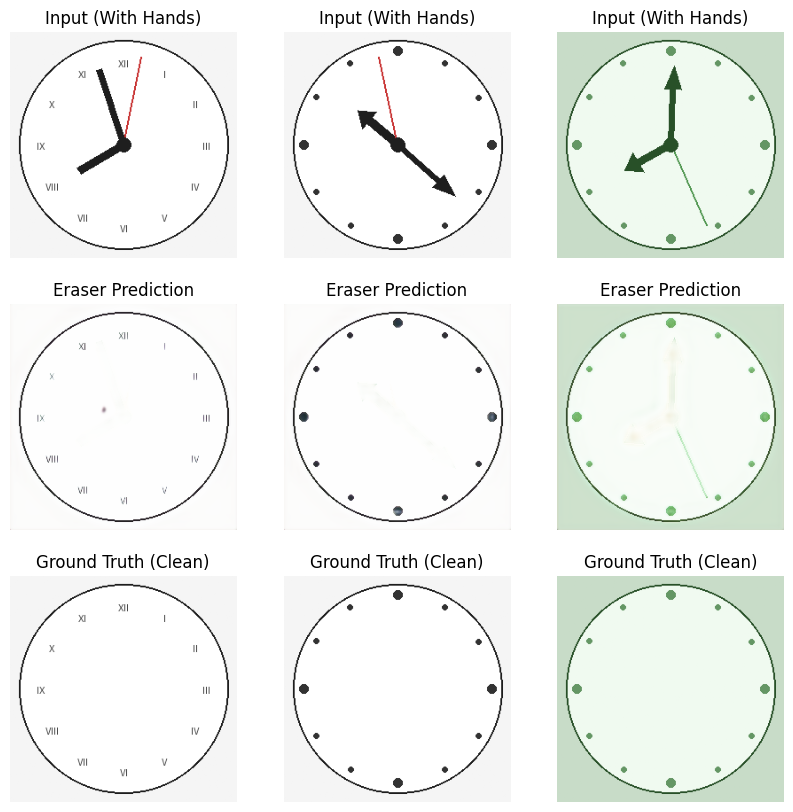

Epoch [11/50], Loss: 0.00173
Epoch [12/50], Loss: 0.00140
Epoch [13/50], Loss: 0.00197
Epoch [14/50], Loss: 0.00100
  -> Saved best model!
Epoch [15/50], Loss: 0.00077
  -> Saved best model!


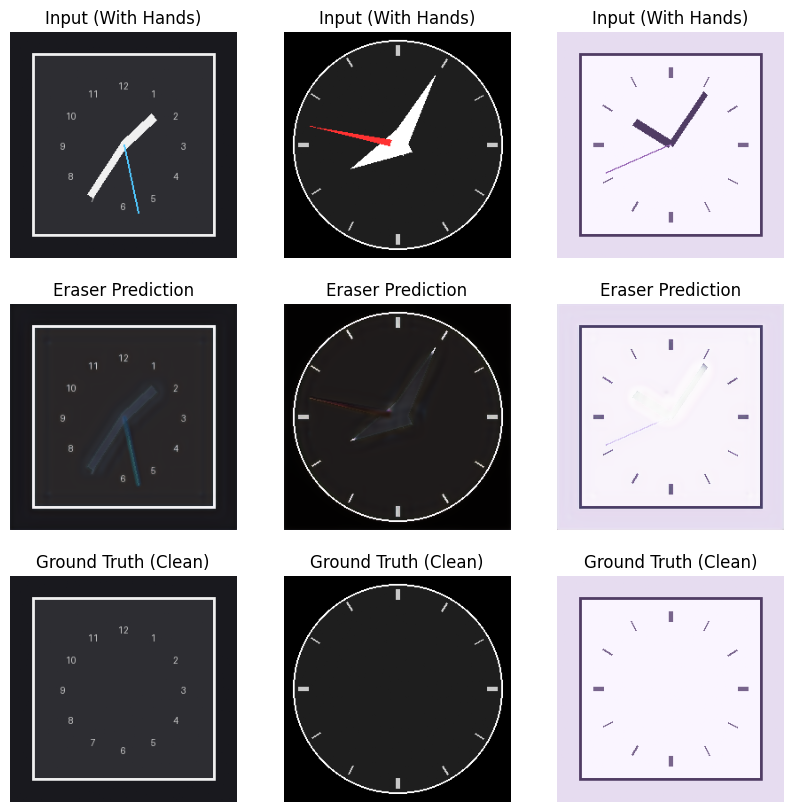

Epoch [16/50], Loss: 0.00077
Epoch [17/50], Loss: 0.00088
Epoch [18/50], Loss: 0.00074
  -> Saved best model!
Epoch [19/50], Loss: 0.00089
Epoch [20/50], Loss: 0.00115


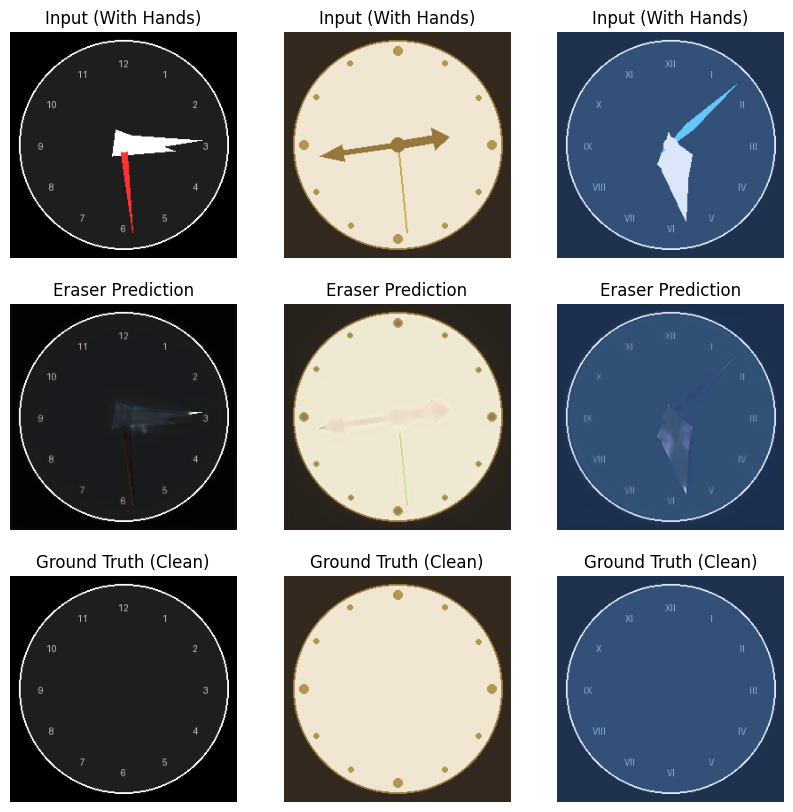

Epoch [21/50], Loss: 0.00063
  -> Saved best model!
Epoch [22/50], Loss: 0.00065
Epoch [23/50], Loss: 0.00054
  -> Saved best model!
Epoch [24/50], Loss: 0.00051
  -> Saved best model!
Epoch [25/50], Loss: 0.00046
  -> Saved best model!


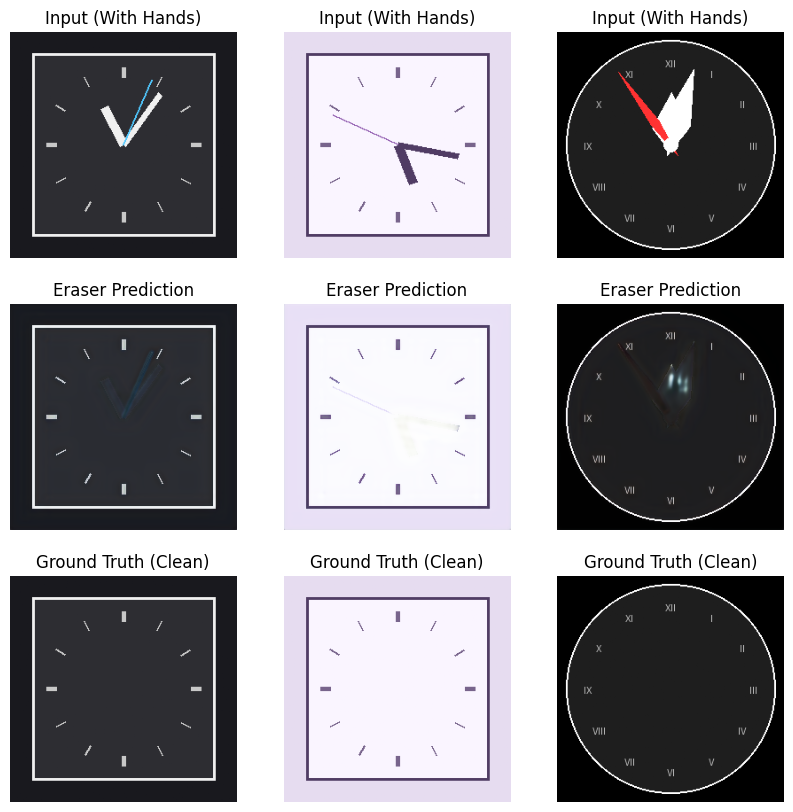

Epoch [26/50], Loss: 0.00081
Epoch [27/50], Loss: 0.00162
Epoch [28/50], Loss: 0.00185
Epoch [29/50], Loss: 0.00198
Epoch [30/50], Loss: 0.00085


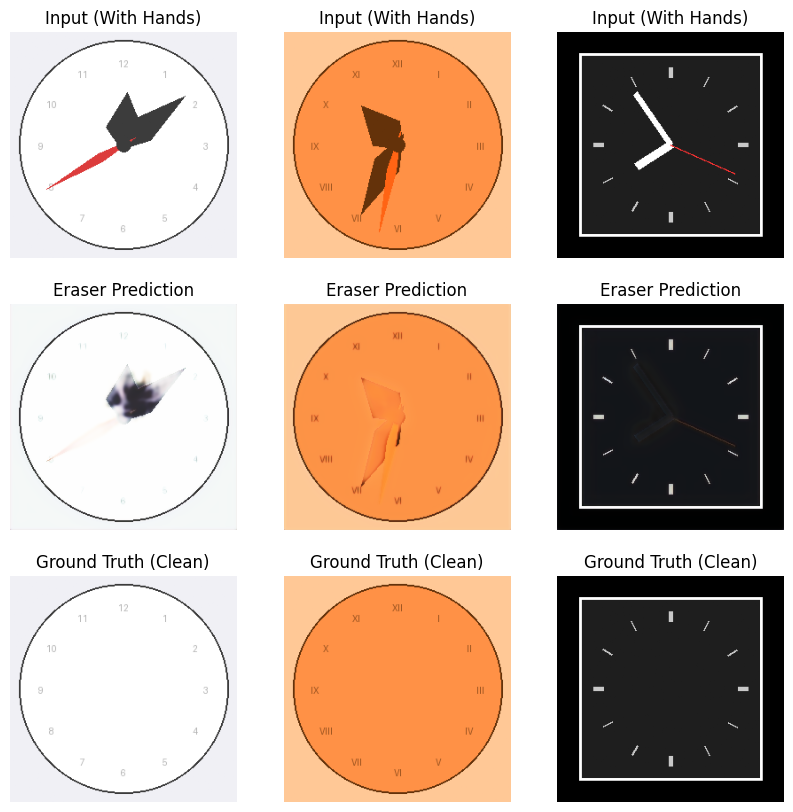

Epoch [31/50], Loss: 0.00081
Epoch [32/50], Loss: 0.00071
Epoch [33/50], Loss: 0.00043
  -> Saved best model!
Epoch [34/50], Loss: 0.00047
Epoch [35/50], Loss: 0.00050


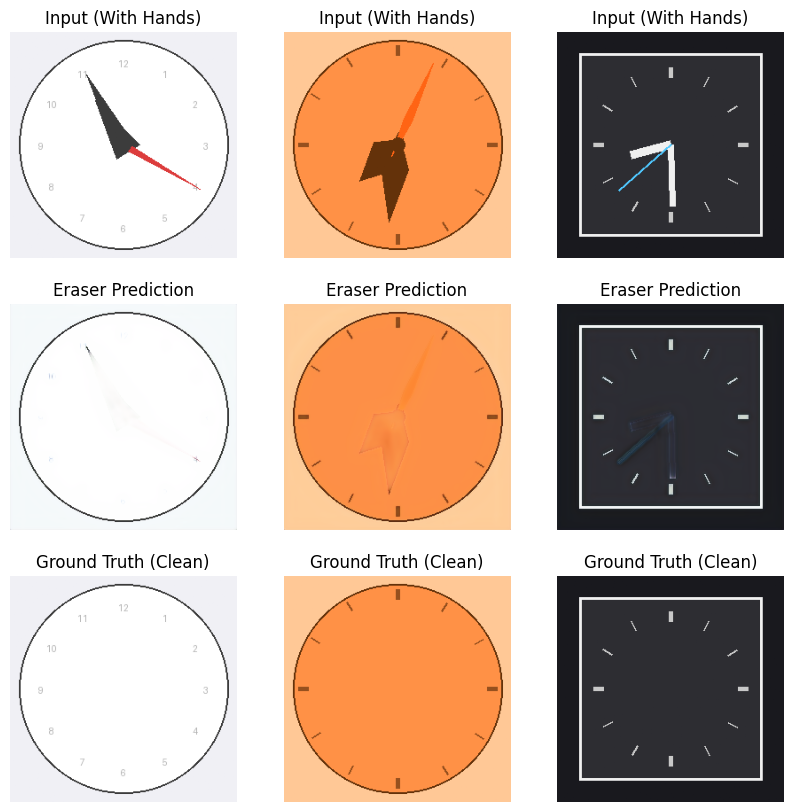

Epoch [36/50], Loss: 0.00044
Epoch [37/50], Loss: 0.00046
Epoch [38/50], Loss: 0.00044
Epoch [39/50], Loss: 0.00051
Epoch [40/50], Loss: 0.00038
  -> Saved best model!


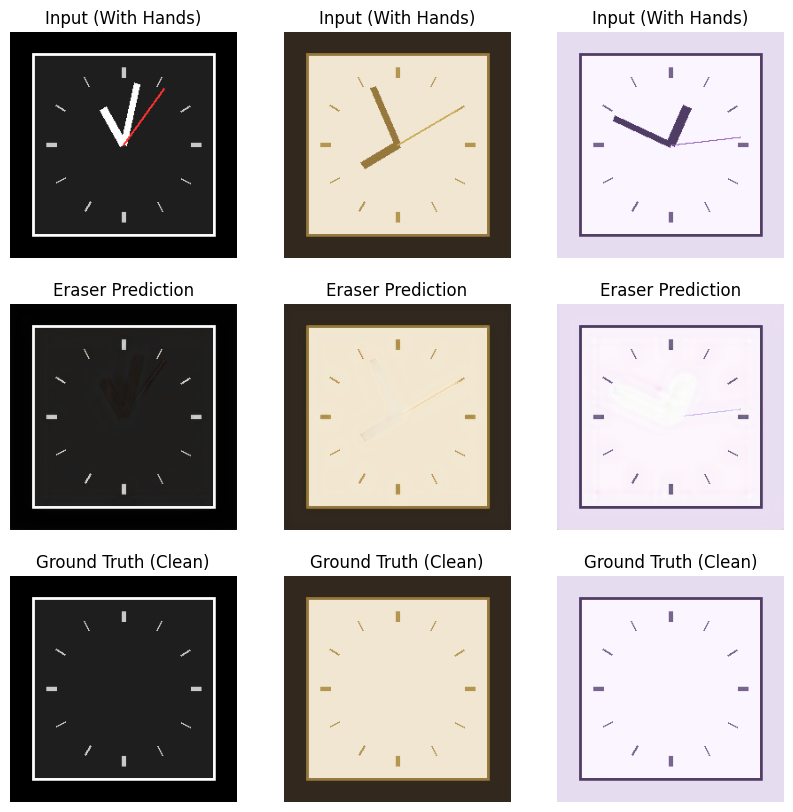

Epoch [41/50], Loss: 0.00031
  -> Saved best model!
Epoch [42/50], Loss: 0.00056
Epoch [43/50], Loss: 0.00089
Epoch [44/50], Loss: 0.00055
Epoch [45/50], Loss: 0.00044


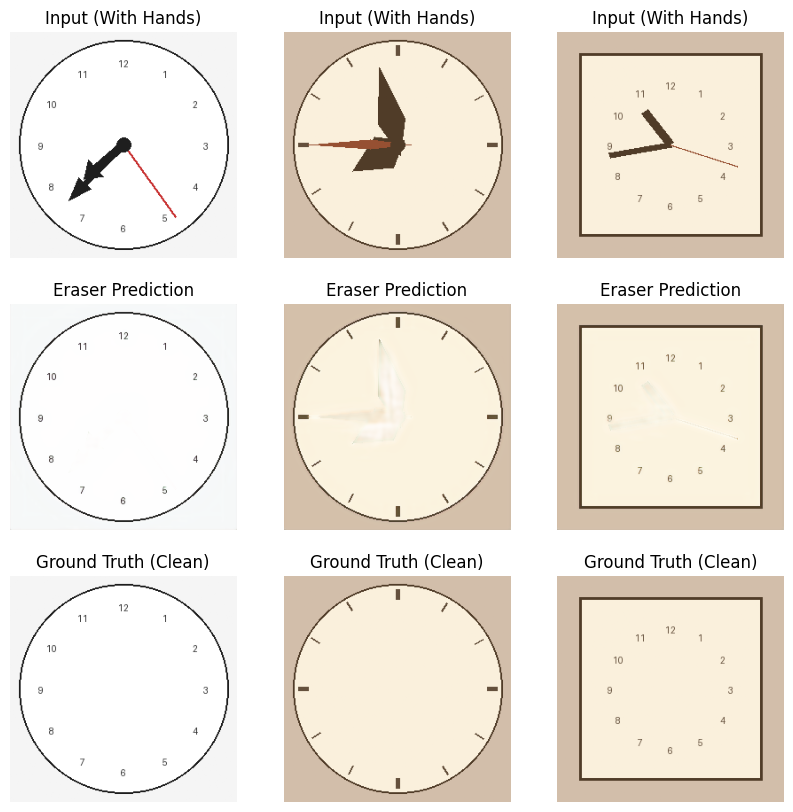

Epoch [46/50], Loss: 0.00037
Epoch [47/50], Loss: 0.00049
Epoch [48/50], Loss: 0.00043
Epoch [49/50], Loss: 0.00029
  -> Saved best model!
Epoch [50/50], Loss: 0.00116


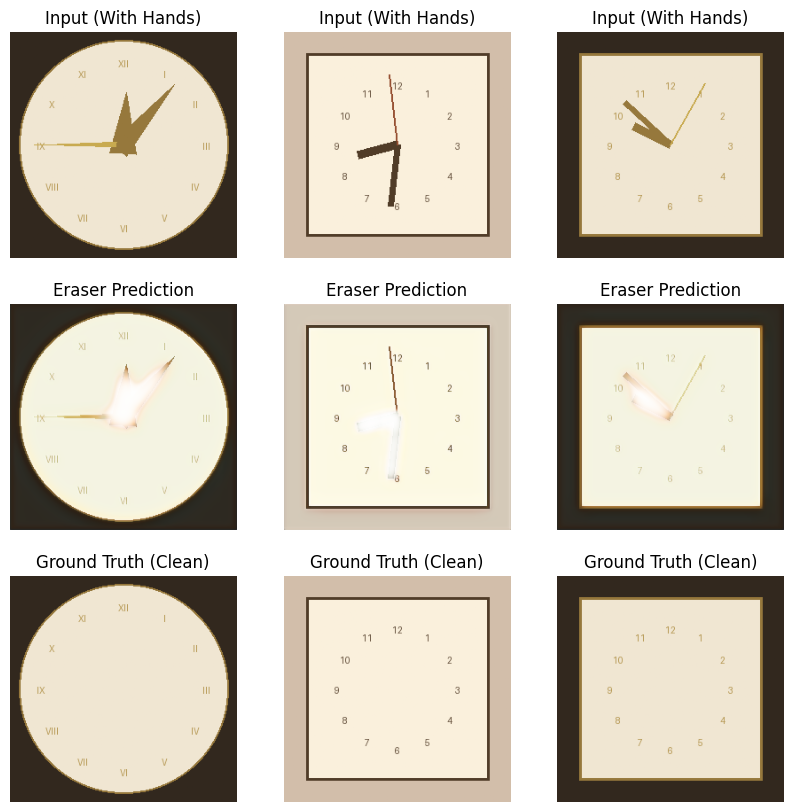

In [4]:

# ===================== Train Function =====================
def train_eraser(data_dir, num_epochs=20, batch_size=16):
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}")

    # Transforms to ensure all images are the same size and normalized
    transform = transforms.Compose([
        transforms.Resize((256, 256)), # Set a fixed size for all images
        transforms.ToTensor(),
    ])

    train_dataset = ClockDataset(data_dir, subset='train', transform=transform)
    test_dataset = ClockDataset(data_dir, subset='test', transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True) # Smaller batch for visualization

    model = ClockEraserUNet().to(device)
    criterion = nn.MSELoss() # L2 Loss for pixel-wise regression
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    os.makedirs('checkpoints', exist_ok=True)
    best_loss = float('inf')

    print("Starting Eraser Training...")
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for batch in train_loader:
            # Inputs: Watch images with hands (analog clock), Targets: Clean clock images (background only)
            inputs = batch['analog_img'].to(device)
            targets = batch['clean_img'].to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.5f}")

        # Save best model
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), "checkpoints/clock_eraser_best.pth")
            print("  -> Saved best model!")

        # Visualize results every 5 epochs
        if (epoch+1) % 5 == 0:
            visualize_results(model, test_loader, device)

def visualize_results(model, loader, device):
    model.eval()
    with torch.no_grad():
        batch = next(iter(loader))
        inputs = batch['analog_img'].to(device)
        targets = batch['clean_img'].to(device)
        outputs = model(inputs)
        
        # Show the first 3 results
        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        for i in range(3):
            if i >= len(inputs): break
            # Input
            axes[0, i].imshow(inputs[i].cpu().permute(1, 2, 0))
            axes[0, i].set_title("Input (With Hands)")
            axes[0, i].axis('off')
            # Output
            axes[1, i].imshow(outputs[i].cpu().permute(1, 2, 0))
            axes[1, i].set_title("Eraser Prediction")
            axes[1, i].axis('off')
            # Target
            axes[2, i].imshow(targets[i].cpu().permute(1, 2, 0))
            axes[2, i].set_title("Ground Truth (Clean)")
            axes[2, i].axis('off')
        plt.show()

if __name__ == "__main__":
    train_eraser(data_dir="../data", num_epochs=50)